In [1]:
import torch
import sys

print("=" * 70)
print("GPU VERIFICATION FOR TRAINING")
print("=" * 70)
print(f"PyTorch Version:   {torch.__version__}")
print(f"CUDA Available:    {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU:               {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory:        {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"CUDA Version:      {torch.version.cuda}")
    
    # Test quick computation
    x = torch.randn(100, 100).cuda()
    y = x @ x.T
    print(f"\n✅ GPU TEST PASSED")
    print(f"   • Tensor creation: ✓")
    print(f"   • Matrix multiply: ✓")
    print(f"   • Ready for training: ✓")
else:
    print(f"\n⚠️  GPU NOT AVAILABLE")
    print(f"   Install CUDA-enabled PyTorch:")
    print(f"   python -m pip install torch torchvision torchaudio \\")
    print(f"       --index-url https://download.pytorch.org/whl/cu121")
    print(f"\n   Then run: python test_gpu.py")
    sys.exit(1)

print("=" * 70)

GPU VERIFICATION FOR TRAINING
PyTorch Version:   2.12.0.dev20260408+cu128
CUDA Available:    True
GPU:               NVIDIA GeForce RTX 5090
GPU Memory:        34.2 GB
CUDA Version:      12.8

✅ GPU TEST PASSED
   • Tensor creation: ✓
   • Matrix multiply: ✓
   • Ready for training: ✓


In [ ]:
convlstm_code = '''
import torch
import torch.nn as nn
from tqdm import tqdm

class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size, padding=padding, bias=True)

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        i, f, g, o = gates.chunk(4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch_size, height, width, device):
        return (
            torch.zeros(batch_size, self.hidden_channels, height, width, device=device),
            torch.zeros(batch_size, self.hidden_channels, height, width, device=device),
        )

class ConvLSTMLayer(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.cell = ConvLSTMCell(in_channels, hidden_channels, kernel_size)

    def forward(self, x_seq, pbar=None):
        B, T, C, H, W = x_seq.shape
        device = x_seq.device
        h, c = self.cell.init_hidden(B, H, W, device)
        for t in range(T):
            h, c = self.cell(x_seq[:, t], h, c)
            if pbar is not None:
                pbar.update(1)
        return h

class ConvLSTMForecaster(nn.Module):
    def __init__(self, in_channels=21, hidden_dims=(64, 128, 64),
                 n_quantiles=10, kernel_size=3, dropout=0.1):
        super().__init__()
        self.n_quantiles = n_quantiles
        self.layer1 = ConvLSTMLayer(in_channels,    hidden_dims[0], kernel_size)
        self.layer2 = ConvLSTMLayer(hidden_dims[0], hidden_dims[1], kernel_size)
        self.layer3 = ConvLSTMLayer(hidden_dims[1], hidden_dims[2], kernel_size)
        # Spatial dropout between stacked layers — regularises against the
        # model memorising per-location patterns instead of learning
        # generalisable spatiotemporal dynamics. Applied to feature maps
        # (not inside the recurrent cell itself, which would destabilise
        # the gates), so it's a no-op at eval time via self.training.
        self.drop1 = nn.Dropout2d(dropout)
        self.drop2 = nn.Dropout2d(dropout)
        self.output_head = nn.Sequential(
            nn.Conv2d(hidden_dims[2], 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(32, n_quantiles, kernel_size=1),
        )

    def forward(self, x_seq, sort_quantiles=False, pbar=None):
        T = x_seq.shape[1]
        h1     = self.drop1(self.layer1(x_seq, pbar=pbar))
        h1_seq = h1.unsqueeze(1).expand(-1, T, -1, -1, -1)
        h2     = self.drop2(self.layer2(h1_seq, pbar=pbar))
        h2_seq = h2.unsqueeze(1).expand(-1, T, -1, -1, -1)
        h3     = self.layer3(h2_seq, pbar=pbar)
        out    = self.output_head(h3)
        if sort_quantiles:
            out, _ = torch.sort(out, dim=1)
        return out

class WeightedPinballLoss(nn.Module):
    def __init__(self, quantile_levels=None,
                 weight_heavy=10.0, weight_avg=3.0, weight_none=1.0,
                 threshold_heavy=95.0, threshold_avg=80.0):
        super().__init__()
        if quantile_levels is None:
            quantile_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
        self.register_buffer("taus",
            torch.tensor(quantile_levels, dtype=torch.float32))
        self.weight_heavy    = weight_heavy
        self.weight_avg      = weight_avg
        self.weight_none     = weight_none
        self.threshold_heavy = threshold_heavy
        self.threshold_avg   = threshold_avg

    def forward(self, pred, target):
        valid_mask = ~torch.isnan(target)
        if valid_mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True, device=pred.device)
        # NaN targets (ocean cells) must be zeroed before any arithmetic —
        # valid_mask alone doesn't suppress them, since NaN * 0 is still NaN
        # and would poison loss_weighted.sum() for the whole batch.
        target = torch.nan_to_num(target, nan=0.0)
        weights = torch.full_like(target, self.weight_none)
        weights = torch.where(target >= self.threshold_avg,
                              torch.full_like(weights, self.weight_avg), weights)
        weights = torch.where(target >= self.threshold_heavy,
                              torch.full_like(weights, self.weight_heavy), weights)
        target_exp = target.unsqueeze(1)
        taus_exp   = self.taus.view(1, -1, 1, 1)
        error      = target_exp - pred
        loss       = torch.where(error >= 0,
                                 taus_exp * error,
                                 (taus_exp - 1) * error)
        loss_mean     = loss.mean(dim=1)
        loss_weighted = loss_mean * weights * valid_mask.float()
        return loss_weighted.sum() / valid_mask.float().sum()
'''

cnn3d_code = '''
import torch
import torch.nn as nn
from tqdm import tqdm
from convlstm_model import WeightedPinballLoss

class Conv3dBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=(3,3,3), stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size,
                      stride=stride, padding=padding, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class CNN3DForecaster(nn.Module):
    # Channel dims scaled to ~1.5M params to match ConvLSTM's capacity
    # (1,540,425 params) for a fair architecture comparison.
    def __init__(self, in_channels=21, n_quantiles=10, dropout=0.15):
        super().__init__()
        self.n_quantiles = n_quantiles
        self.block1 = Conv3dBlock(in_channels, 64,
                                  kernel_size=(3,3,3), padding=(1,1,1))
        self.block2 = Conv3dBlock(64, 128,
                                  kernel_size=(3,3,3),
                                  stride=(2,1,1), padding=(1,1,1))
        self.block3 = Conv3dBlock(128, 256,
                                  kernel_size=(3,3,3),
                                  stride=(2,1,1), padding=(1,1,1))
        self.block4 = Conv3dBlock(256, 128,
                                  kernel_size=(3,3,3),
                                  stride=(3,1,1), padding=(1,1,1))
        # Spatial dropout between blocks — same rationale as ConvLSTM:
        # regularises against memorising per-location patterns (train/val
        # share the same ~2,501 locations, differing only in time period).
        self.drop2 = nn.Dropout3d(dropout)
        self.drop3 = nn.Dropout3d(dropout)
        self.output_head = nn.Sequential(
            nn.Conv2d(128, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(32, n_quantiles, kernel_size=1),
        )

    def forward(self, x_seq, sort_quantiles=False, pbar=None):
        x = x_seq.permute(0, 2, 1, 3, 4)
        x = self.block1(x)
        if pbar is not None: pbar.update(1)
        x = self.drop2(self.block2(x))
        if pbar is not None: pbar.update(1)
        x = self.drop3(self.block3(x))
        if pbar is not None: pbar.update(1)
        x = self.block4(x)
        if pbar is not None: pbar.update(1)
        x   = x.squeeze(2)
        out = self.output_head(x)
        if sort_quantiles:
            out, _ = torch.sort(out, dim=1)
        return out
'''

# Write both files to THESIS_PROJECT directory
with open("convlstm_model.py", "w") as f:
    f.write(convlstm_code)
print("✓ Written convlstm_model.py")

with open("cnn3d_model.py", "w") as f:
    f.write(cnn3d_code)
print("✓ Written cnn3d_model.py")

# CONVLSTM

In [ ]:
# CONVLSTM MODEL — PROBABILISTIC UK FLOOD NOWCASTING
# ============================================================================
# Architecture: ConvLSTM encoder → quantile output head
#
# Input:  (B, T, C, H, W) = (B, 12, 21, 140, 131)
# Output: (B, 9, H, W)    = (B, 9,  140, 131)
#         9 quantile estimates (τ = 0.1, 0.2, ..., 0.9)
#
# Loss: Weighted pinball loss (≈ CRPS)
#       heavy flood ×10, average flood ×3, no flood ×1
# ============================================================================
import torch
import torch.nn as nn
from tqdm import tqdm


# ── ConvLSTM Cell ──────────────────────────────────────────────────────────

class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        padding   = kernel_size // 2
        self.conv = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size, padding=padding, bias=True
        )

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates    = self.conv(combined)
        i, f, g, o = gates.chunk(4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch_size, height, width, device):
        return (
            torch.zeros(batch_size, self.hidden_channels,
                        height, width, device=device),
            torch.zeros(batch_size, self.hidden_channels,
                        height, width, device=device),
        )


# ── ConvLSTM Layer ─────────────────────────────────────────────────────────

class ConvLSTMLayer(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.cell = ConvLSTMCell(in_channels, hidden_channels, kernel_size)

    def forward(self, x_seq, pbar=None):
        """
        Args:
            x_seq : (B, T, C, H, W)
            pbar  : optional tqdm bar to update per timestep
        Returns:
            h : (B, hidden_channels, H, W) final hidden state
        """
        B, T, C, H, W = x_seq.shape
        device = x_seq.device
        h, c = self.cell.init_hidden(B, H, W, device)
        for t in range(T):
            h, c = self.cell(x_seq[:, t], h, c)
            if pbar is not None:
                pbar.update(1)
        return h


# ── Full ConvLSTM Model ────────────────────────────────────────────────────

class ConvLSTMForecaster(nn.Module):
    """
    Three-layer ConvLSTM encoder with 9-channel quantile output head.

    Layers:
        Layer 1: 21  → 64  channels
        Layer 2: 64  → 128 channels
        Layer 3: 128 → 64  channels
        Output:  64  → 9   channels (1×1 conv)
    """
    def __init__(self, in_channels=21, hidden_dims=(64, 128, 64),
                 n_quantiles=10, kernel_size=3, dropout=0.15):
        super().__init__()
        self.n_quantiles = n_quantiles
        self.layer1 = ConvLSTMLayer(in_channels,    hidden_dims[0], kernel_size)
        self.layer2 = ConvLSTMLayer(hidden_dims[0], hidden_dims[1], kernel_size)
        self.layer3 = ConvLSTMLayer(hidden_dims[1], hidden_dims[2], kernel_size)
        # Spatial dropout between stacked layers — regularises against the
        # model memorising per-location patterns (train/val share the same
        # ~2,501 locations, differing only in time period).
        self.drop1 = nn.Dropout2d(dropout)
        self.drop2 = nn.Dropout2d(dropout)
        self.output_head = nn.Sequential(
            nn.Conv2d(hidden_dims[2], 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(32, n_quantiles, kernel_size=1),
        )

    def forward(self, x_seq, sort_quantiles=False, pbar=None):
        """
        Args:
            x_seq         : (B, T, C, H, W)
            sort_quantiles: sort outputs at inference to prevent crossing
            pbar          : optional tqdm bar (updated per timestep per layer)
        """
        T = x_seq.shape[1]

        h1     = self.drop1(self.layer1(x_seq, pbar=pbar))
        h1_seq = h1.unsqueeze(1).expand(-1, T, -1, -1, -1)
        h2     = self.drop2(self.layer2(h1_seq, pbar=pbar))
        h2_seq = h2.unsqueeze(1).expand(-1, T, -1, -1, -1)
        h3     = self.layer3(h2_seq, pbar=pbar)

        out = self.output_head(h3)

        if sort_quantiles:
            out, _ = torch.sort(out, dim=1)
        return out


# ── Weighted Pinball Loss ──────────────────────────────────────────────────

class WeightedPinballLoss(nn.Module):
    """
    Pinball loss averaged across 9 quantile levels (≈ CRPS).
    Sample weights address 27:6:1 class imbalance:
        heavy flood (≥ 95) : ×10
        average flood (80–95): ×3
        no flood (< 80)    : ×1
    """
    def __init__(self, quantile_levels=None,
                 weight_heavy=10.0, weight_avg=3.0, weight_none=1.0,
                 threshold_heavy=95.0, threshold_avg=80.0):
        super().__init__()
        if quantile_levels is None:
            quantile_levels = [0.1, 0.2, 0.3, 0.4, 0.5,
                                0.6, 0.7, 0.8, 0.9]
        self.register_buffer('taus',
            torch.tensor(quantile_levels, dtype=torch.float32))
        self.weight_heavy    = weight_heavy
        self.weight_avg      = weight_avg
        self.weight_none     = weight_none
        self.threshold_heavy = threshold_heavy
        self.threshold_avg   = threshold_avg

    def forward(self, pred, target):
        valid_mask = ~torch.isnan(target)
        if valid_mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True, device=pred.device)

    # Replace NaN targets with 0 for computation (masked out anyway)
        target_clean = target.clone()
        target_clean[~valid_mask] = 0.0

        weights = torch.full_like(target_clean, self.weight_none)
        weights = torch.where(target_clean >= self.threshold_avg,
                          torch.full_like(weights, self.weight_avg), weights)
        weights = torch.where(target_clean >= self.threshold_heavy,
                          torch.full_like(weights, self.weight_heavy), weights)

        target_exp = target_clean.unsqueeze(1)
        taus_exp   = self.taus.view(1, -1, 1, 1)
        error      = target_exp - pred
        loss       = torch.where(error >= 0,
                             taus_exp * error,
                             (taus_exp - 1) * error)
        loss_mean     = loss.mean(dim=1)
        loss_weighted = loss_mean * weights * valid_mask.float()
        return loss_weighted.sum() / valid_mask.float().sum()

# ── Sanity Check ──────────────────────────────────────────────────────────

if __name__ == "__main__":
    device = torch.device("cpu")
    B, T, C, H, W = 2, 12, 21, 140, 131

    model     = ConvLSTMForecaster(in_channels=21,
                                    hidden_dims=(64, 128, 64),
                                    n_quantiles=9).to(device)
    criterion = WeightedPinballLoss()

    x      = torch.randn(B, T, C, H, W)
    target = torch.rand(B, H, W) * 100         # guaranteed 0-100 range
    target[0, :5, :5] = float('nan')

    # Progress bar for sanity check forward pass
    total_steps = 3 * T  # 3 layers × T timesteps
    with tqdm(total=total_steps, desc="ConvLSTM forward pass",
              unit="step",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} timesteps "
                         "[{elapsed}<{remaining}]") as pbar:
        pred = model(x, sort_quantiles=False, pbar=pbar)

    loss = criterion(pred, target)

    print(f"\nInput shape:  {x.shape}")
    print(f"Output shape: {pred.shape}")
    print(f"Target shape: {target.shape}")
    print(f"Pinball loss: {loss.item():.4f}")
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters:   {n_params:,}")
    print("✓ ConvLSTM architecture check passed")

In [5]:
import torch
import sys
sys.path.insert(0, "D:/")
from convlstm_model import ConvLSTMForecaster, WeightedPinballLoss
device = torch.device("cpu")
B, T, C, H, W = 2, 12, 21, 140, 131

model     = ConvLSTMForecaster().to(device)
criterion = WeightedPinballLoss()

x      = torch.randn(B, T, C, H, W)
target = torch.rand(B, H, W) * 100    # guaranteed 0-100, no negatives
target[0, :5, :5] = float('nan')      # sea cells

pred = model(x)
loss = criterion(pred, target)
print(f"Loss with valid target: {loss.item():.4f}")
print(f"Pred range: [{pred.min():.2f}, {pred.max():.2f}]")
print(f"Any NaN in pred: {pred.isnan().any()}")

Loss with valid target: nan
Pred range: [-0.15, 0.17]
Any NaN in pred: False


# 3D CNN

In [2]:
from cnn3d_model import CNN3DForecaster
from convlstm_model import WeightedPinballLoss
from tqdm import tqdm
import torch

device = torch.device("cpu")
B, T, C, H, W = 2, 12, 21, 140, 131

model     = CNN3DForecaster().to(device)
criterion = WeightedPinballLoss()

x      = torch.randn(B, T, C, H, W)
target = torch.rand(B, H, W) * 100
target[0, :5, :5] = float('nan')

with tqdm(total=4, desc="3D-CNN forward pass", unit="block",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} blocks "
                     "[{elapsed}<{remaining}]") as pbar:
    pred = model(x, sort_quantiles=False, pbar=pbar)

loss = criterion(pred, target)

print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {pred.shape}")
print(f"Target shape: {target.shape}")
print(f"Pinball loss: {loss.item():.4f}")
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters:   {n_params:,}")
print("✓ 3D-CNN architecture check passed")


3D-CNN forward pass:   0%|          | 0/4 blocks [00:00<?]


3D-CNN forward pass:  25%|██▌       | 1/4 blocks [00:00<00:00]


3D-CNN forward pass:  75%|███████▌  | 3/4 blocks [00:00<00:00]


3D-CNN forward pass: 100%|██████████| 4/4 blocks [00:00<00:00]


Input shape:  torch.Size([2, 12, 21, 140, 131])
Output shape: torch.Size([2, 9, 140, 131])
Target shape: torch.Size([2, 140, 131])
Pinball loss: 60.5878
Parameters:   2,065,289
✓ 3D-CNN architecture check passed


In [ ]:
# 3D-CNN MODEL — PROBABILISTIC UK FLOOD NOWCASTING
# ============================================================================
# Channel dimensions scaled to match ConvLSTM parameter count (~1.5M):
#   Block 1: 20  -> 64  channels
#   Block 2: 64  -> 128 channels
#   Block 3: 128 -> 256 channels
#   Block 4: 256 -> 128 channels
# This mirrors cnn3d_model.py exactly (source of truth for training).
# ============================================================================
import torch
import torch.nn as nn
from tqdm import tqdm


class Conv3dBlock(nn.Module):
    """3D Conv -> BatchNorm3d -> ReLU"""
    def __init__(self, in_ch, out_ch,
                 kernel_size=(3, 3, 3),
                 stride=(1, 1, 1),
                 padding=(1, 1, 1)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch,
                      kernel_size=kernel_size,
                      stride=stride,
                      padding=padding,
                      bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class CNN3DForecaster(nn.Module):
    """
    Four-layer 3D-CNN encoder with temporal collapse and
    9-channel quantile output head.

    Channel dimensions scaled to match ConvLSTM (~1.5M parameters):
        Block 1: (20,  12, H, W) -> (64,  12, H, W)
        Block 2: (64,  12, H, W) -> (128,  6, H, W)  stride=(2,1,1)
        Block 3: (128,  6, H, W) -> (256,  3, H, W)  stride=(2,1,1)
        Block 4: (256,  3, H, W) -> (128,  1, H, W)  stride=(3,1,1)
        Squeeze -> (128, H, W)
        Output:  (128, H, W)    -> (9,   H, W)

    Spatial dropout between blocks 2/3 and in the output head regularises
    against memorising per-location patterns (train/val share the same
    ~2,501 locations, differing only in time period).
    """
    def __init__(self, in_channels=21, n_quantiles=10, dropout=0.15):
        super().__init__()
        self.n_quantiles = n_quantiles

        self.block1 = Conv3dBlock(in_channels, 64,
                                  kernel_size=(3, 3, 3),
                                  stride=(1, 1, 1),
                                  padding=(1, 1, 1))
        self.block2 = Conv3dBlock(64, 128,
                                  kernel_size=(3, 3, 3),
                                  stride=(2, 1, 1),
                                  padding=(1, 1, 1))
        self.block3 = Conv3dBlock(128, 256,
                                  kernel_size=(3, 3, 3),
                                  stride=(2, 1, 1),
                                  padding=(1, 1, 1))
        self.block4 = Conv3dBlock(256, 128,
                                  kernel_size=(3, 3, 3),
                                  stride=(3, 1, 1),
                                  padding=(1, 1, 1))
        self.drop2 = nn.Dropout3d(dropout)
        self.drop3 = nn.Dropout3d(dropout)

        self.output_head = nn.Sequential(
            nn.Conv2d(128, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(32, n_quantiles, kernel_size=1),
        )

    def forward(self, x_seq, sort_quantiles=False, pbar=None):
        """
        Args:
            x_seq         : (B, T, C, H, W)
            sort_quantiles: sort outputs at inference to prevent crossing
            pbar          : optional tqdm bar (updated per block)
        """
        x = x_seq.permute(0, 2, 1, 3, 4)
        x = self.block1(x)
        if pbar is not None: pbar.update(1)
        x = self.drop2(self.block2(x))
        if pbar is not None: pbar.update(1)
        x = self.drop3(self.block3(x))
        if pbar is not None: pbar.update(1)
        x = self.block4(x)
        if pbar is not None: pbar.update(1)
        x   = x.squeeze(2)
        out = self.output_head(x)
        if sort_quantiles:
            out, _ = torch.sort(out, dim=1)
        return out


# -- Sanity Check --------------------------------------------------------
from convlstm_model import WeightedPinballLoss
from cnn3d_model import CNN3DForecaster
from tqdm import tqdm
import torch

device = torch.device("cpu")
B, T, C, H, W = 2, 12, 21, 140, 131

model     = CNN3DForecaster().to(device)
criterion = WeightedPinballLoss()

x      = torch.randn(B, T, C, H, W)
target = torch.rand(B, H, W) * 100
target[0, :5, :5] = float('nan')

with tqdm(total=4, desc="3D-CNN") as pbar:
    pred = model(x, pbar=pbar)

loss = criterion(pred, target)
print(f"Loss: {loss.item():.4f}")
print(f"Pred range: [{pred.min():.3f}, {pred.max():.3f}]")
print(f"NaN in pred: {pred.isnan().any()}")
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")


In [8]:
import torch
import torch.nn as nn

class WeightedPinballLoss(nn.Module):
    def __init__(self, quantile_levels=None,
                 weight_heavy=10.0, weight_avg=3.0, weight_none=1.0,
                 threshold_heavy=95.0, threshold_avg=80.0):
        super().__init__()
        if quantile_levels is None:
            quantile_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
        self.register_buffer('taus',
            torch.tensor(quantile_levels, dtype=torch.float32))
        self.weight_heavy    = weight_heavy
        self.weight_avg      = weight_avg
        self.weight_none     = weight_none
        self.threshold_heavy = threshold_heavy
        self.threshold_avg   = threshold_avg

    def forward(self, pred, target):
        valid_mask = ~torch.isnan(target)
        if valid_mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True, device=pred.device)

        target_clean = target.clone()
        target_clean[~valid_mask] = 0.0

        weights = torch.full_like(target_clean, self.weight_none)
        weights = torch.where(target_clean >= self.threshold_avg,
                              torch.full_like(weights, self.weight_avg), weights)
        weights = torch.where(target_clean >= self.threshold_heavy,
                              torch.full_like(weights, self.weight_heavy), weights)

        target_exp = target_clean.unsqueeze(1)
        taus_exp   = self.taus.to(pred.device).view(1, -1, 1, 1)  # ← GPU fix
        error      = target_exp - pred
        loss       = torch.where(error >= 0,
                                 taus_exp * error,
                                 (taus_exp - 1) * error)
        loss_mean     = loss.mean(dim=1)
        loss_weighted = loss_mean * weights * valid_mask.float()
        return loss_weighted.sum() / valid_mask.float().sum()

print("✓ WeightedPinballLoss redefined with GPU fix")

✓ WeightedPinballLoss redefined with GPU fix


In [ ]:
# TRAIN CONVLSTM — BINARY DATA VERSION (GPU OPTIMISED)
# ============================================================================
# Reads pre-converted binary .npy files instead of CSV — 10-20x faster.
# Optimised for: Intel Core Ultra 9 285K, 64GB RAM, RTX 5090 32GB VRAM
# Windows-safe: num_workers=0, if __name__ == '__main__' guard
# Expected runtime: 2-4 hours for 40 epochs (ConvLSTM slower than 3D-CNN
# due to recurrent processing — 3x more compute per batch)
# ============================================================================
import os
import time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from convlstm_model import ConvLSTMForecaster, WeightedPinballLoss

# ── Paths ──
SEAGATE        = r"W:\Dissertation\Volumes\Seagate_2TB"
TRAIN_X_PATH   = os.path.join(SEAGATE, "train_X.npy")
TRAIN_Y_PATH   = os.path.join(SEAGATE, "train_y.npy")
VAL_X_PATH     = os.path.join(SEAGATE, "val_X.npy")
VAL_Y_PATH     = os.path.join(SEAGATE, "val_y.npy")
CHECKPOINT_DIR = os.path.join(SEAGATE, "model_checkpoints", "ConvLSTM")
LOG_DIR        = os.path.join(SEAGATE, "model_logs")
CSV_PATH       = r"W:\Dissertation\merged_output_hourly_imerg\merged_data_normalised.csv"

# ── Config ──
N_LAT       = 140
N_LON       = 131
N_FEATURES  = 20
N_QUANTILES = 9
SEQ_LEN     = 12
PATCH_SIZE  = 64
HALF        = PATCH_SIZE // 2
BATCH_SIZE  = 48    # batch 256 OOMs the 32GB 5090 (backprop through 12
                     # timesteps x 3 ConvLSTM layers needed ~58GB); with
                     # AMP this fits comfortably with headroom to spare
N_EPOCHS    = 40
LR          = 3e-4  # base LR after warmup — 1e-4 was tried and scored
                     # *worse* (best val 16.07 vs 15.63), so the epoch-1
                     # plateau isn't primarily an LR problem; kept dynamic
                     # via warmup + ReduceLROnPlateau below instead of a
                     # single guessed value
WARMUP_EPOCHS = 3    # linear ramp 0.1*LR -> LR, avoids the first few
                     # noisy/large gradients (before the running loss
                     # signal is meaningful) taking an oversized step
DROPOUT     = 0.15   # spatial dropout between ConvLSTM layers — see
                     # convlstm_model.py; regularises against memorising
                     # per-location patterns (train/val share locations)
PATIENCE    = 10
SAVE_EVERY  = 5
TARGET_COL  = "flood_composite_6h_ahead"


# ── Dataset ──
class BinaryPatchDataset(Dataset):
    def __init__(self, X, y, centres, n_hours):
        self.X        = X
        self.y        = y
        self.centres  = centres
        self.seq_ends = list(range(SEQ_LEN, n_hours))

    def __len__(self):
        return len(self.seq_ends)

    def _patch(self, grid, lat_c, lon_c):
        return grid[...,
                    lat_c - HALF:lat_c + HALF,
                    lon_c - HALF:lon_c + HALF].copy()

    def __getitem__(self, idx):
        seq_end      = self.seq_ends[idx]
        ci           = np.random.randint(0, len(self.centres))
        lat_c, lon_c = self.centres[ci]
        x_seq = np.stack([
            self._patch(self.X[h], lat_c, lon_c)
            for h in range(seq_end - SEQ_LEN, seq_end)
        ])
        y = self._patch(self.y[seq_end][np.newaxis], lat_c, lon_c)[0]
        return (torch.from_numpy(x_seq).float(),
                torch.from_numpy(y).float())


if __name__ == '__main__':
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    os.makedirs(LOG_DIR, exist_ok=True)

    # ── Device ──
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    if device.type == "cuda":
        torch.backends.cudnn.benchmark        = True
        torch.backends.cuda.matmul.allow_tf32 = True
        print(f"GPU:  {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    else:
        print("⚠ CUDA not available — running on CPU")

    # ── Load data into RAM ──
    print("\nLoading binary data into RAM...")
    t0 = time.time()

    print("  Loading train (22.5GB — ~2 min)...")
    train_X = np.load(TRAIN_X_PATH)
    train_y = np.load(TRAIN_Y_PATH)
    print(f"  Train: {train_X.shape} — {train_X.nbytes/1e9:.1f} GB")

    print("  Loading val (3.2GB)...")
    val_X = np.load(VAL_X_PATH)
    val_y = np.load(VAL_Y_PATH)
    print(f"  Val:   {val_X.shape} — {val_X.nbytes/1e9:.1f} GB")
    print(f"  Total load time: {(time.time()-t0)/60:.1f} min")

    N_TRAIN = train_X.shape[0]
    N_VAL   = val_X.shape[0]

    # ── Land cell index ──
    print("\nBuilding land cell index...")
    header_cols  = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()
    SKIP_COLS    = {"time", "latitude", "longitude", TARGET_COL}
    FEATURE_COLS = [c for c in header_cols if c not in SKIP_COLS]
    land_idx     = FEATURE_COLS.index("is_land")

    # Find land cells from channel with most nonzero values if is_land all zero
    land_mask = train_X[0, land_idx]
    if land_mask.max() == 0:
        print("  ⚠ is_land channel all zero — using soil_average_soil instead")
        soil_idx  = FEATURE_COLS.index("soil_average_soil")
        land_mask = train_X[0, soil_idx]

    valid_centres = [
        (lat, lon)
        for lat in range(HALF, N_LAT - HALF)
        for lon in range(HALF, N_LON - HALF)
        if land_mask[lat, lon] > 0.0
    ]
    print(f"Valid patch centres: {len(valid_centres):,}")

    if len(valid_centres) == 0:
        # Fallback — use all interior cells
        print("  ⚠ No valid centres found — using all interior cells")
        valid_centres = [
            (lat, lon)
            for lat in range(HALF, N_LAT - HALF)
            for lon in range(HALF, N_LON - HALF)
        ]
        print(f"  Fallback centres: {len(valid_centres):,}")

    # ── Feature standardisation (train-only stats, no val leakage) ──
    # "merged_data_normalised.csv" is a misnomer — that step only cleans
    # timestamp/coordinate formatting, it does no statistical scaling
    # (confirmed: era5_t2m sits at ~285, i.e. raw Kelvin). Channels here
    # span wildly different raw scales (Kelvin ~285, precip in mm, 0/1
    # land flags, soil fractions), which likely contributed to the fast
    # train-loss plateau. Stats are computed from train_X ONLY and reused
    # for val_X, so no validation-period information leaks into training.
    print("\nStandardising features (train-only stats)...")
    chan_mean = train_X.mean(axis=(0, 2, 3), keepdims=True).astype(np.float32)
    chan_std  = train_X.std(axis=(0, 2, 3), keepdims=True).astype(np.float32)
    chan_std[chan_std < 1e-6] = 1.0  # constant channels (e.g. is_land is
                                      # still 0/1 after fill) — avoid /0
    np.save(os.path.join(CHECKPOINT_DIR, "feature_mean.npy"), chan_mean)
    np.save(os.path.join(CHECKPOINT_DIR, "feature_std.npy"), chan_std)
    train_X -= chan_mean
    train_X /= chan_std
    val_X   -= chan_mean
    val_X   /= chan_std
    print(f"  Done. Stats saved to {CHECKPOINT_DIR}\\feature_{{mean,std}}.npy")

    # ── Datasets ──
    print("\nBuilding datasets...")
    train_dataset = BinaryPatchDataset(
        train_X, train_y, valid_centres, N_TRAIN)
    val_dataset   = BinaryPatchDataset(
        val_X, val_y, valid_centres, N_VAL)
    print(f"  Train sequences: {len(train_dataset):,}")
    print(f"  Val sequences:   {len(val_dataset):,}")

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        shuffle=True,  num_workers=0,
        pin_memory=(device.type == "cuda"),
        drop_last=True)

    val_loader = DataLoader(
        val_dataset,   batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0,
        pin_memory=(device.type == "cuda"),
        drop_last=False)

    print(f"  Train batches/epoch: {len(train_loader):,}")
    print(f"  Val batches/epoch:   {len(val_loader):,}")

    # ── Model ──
    model = ConvLSTMForecaster(
        in_channels=N_FEATURES,
        hidden_dims=(64, 128, 64),
        n_quantiles=N_QUANTILES,
        dropout=DROPOUT).to(device)

    # Wrap with DataParallel if multiple GPUs available
    if torch.cuda.device_count() > 1:
        print(f"\nUsing {torch.cuda.device_count()} GPUs with DataParallel")
        model = torch.nn.DataParallel(model)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nConvLSTM parameters: {n_params:,}")

    optimizer = torch.optim.Adam(
        model.parameters(), lr=LR * 0.1, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
    criterion = WeightedPinballLoss().to(device)
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))

    best_val   = np.inf
    patience_c = 0
    log        = []
    t_start    = time.time()

    print(f"\nStarting ConvLSTM — {N_EPOCHS} epochs")
    print(f"Batch: {BATCH_SIZE} | Patch: {PATCH_SIZE}×{PATCH_SIZE}")
    print(f"Checkpoints → {CHECKPOINT_DIR}\n")

    # ── Training loop ──
    with tqdm(total=N_EPOCHS, desc="ConvLSTM", unit="epoch",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} epochs "
                         "[{elapsed}<{remaining}] {postfix}") as ebar:

        for epoch in range(N_EPOCHS):
            t_ep = time.time()

            # Dynamic LR: linear warmup for the first WARMUP_EPOCHS (from
            # 0.1*LR to LR), then ReduceLROnPlateau takes over — avoids an
            # oversized early step while the loss signal is still noisy,
            # then adapts to the actual val-loss trend afterwards.
            if epoch < WARMUP_EPOCHS:
                warmup_lr = LR * 0.1 + (LR - LR * 0.1) * (epoch + 1) / WARMUP_EPOCHS
                for g in optimizer.param_groups:
                    g['lr'] = warmup_lr

            # Train
            model.train()
            train_loss = 0.0
            n_train    = 0

            with tqdm(total=len(train_loader),
                      desc=f"  Train ep{epoch+1:2d}",
                      unit="batch", leave=False,
                      bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} "
                                 "[{elapsed}<{remaining}, {rate_fmt}] "
                                 "{postfix}") as bbar:
                for x, y in train_loader:
                    x = x.to(device, non_blocking=True)
                    y = y.to(device, non_blocking=True)
                    optimizer.zero_grad(set_to_none=True)
                    with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                        pred = model(x)
                        loss = criterion(pred, y)
                    if torch.isnan(loss):
                        bbar.update(1)
                        continue
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    train_loss += loss.item()
                    n_train    += 1
                    bbar.set_postfix(
                        loss=f"{loss.item():.4f}", refresh=False)
                    bbar.update(1)

            avg_train = train_loss / max(n_train, 1)

            # Validate
            model.eval()
            val_loss = 0.0
            n_val    = 0

            with torch.no_grad():
                with tqdm(total=len(val_loader),
                          desc=f"  Val   ep{epoch+1:2d}",
                          unit="batch", leave=False,
                          bar_format="{l_bar}{bar}| "
                                     "{n_fmt}/{total_fmt} "
                                     "[{elapsed}<{remaining}]") as vbar:
                    for x, y in val_loader:
                        x = x.to(device, non_blocking=True)
                        y = y.to(device, non_blocking=True)
                        with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                            pred = model(x, sort_quantiles=True)
                            loss = criterion(pred, y)
                        if not torch.isnan(loss):
                            val_loss += loss.item()
                            n_val    += 1
                        vbar.update(1)

            avg_val   = val_loss / max(n_val, 1)
            epoch_min = (time.time() - t_ep) / 60
            elapsed   = (time.time() - t_start) / 60
            if epoch >= WARMUP_EPOCHS:
                scheduler.step(avg_val)  # plateau-adaptive only after warmup
            cur_lr = optimizer.param_groups[0]['lr']

            vram_gb = (torch.cuda.memory_allocated() / 1e9
                       if device.type == "cuda" else 0.0)

            log.append({"epoch": epoch+1, "train_loss": avg_train,
                        "val_loss": avg_val, "lr": cur_lr,
                        "epoch_min": epoch_min})

            ebar.set_postfix(
                train=f"{avg_train:.4f}", val=f"{avg_val:.4f}",
                best=f"{best_val:.4f}", lr=f"{cur_lr:.2e}",
                ep_min=f"{epoch_min:.1f}min",
                vram=f"{vram_gb:.1f}GB")
            ebar.update(1)

            if avg_val < best_val:
                best_val   = avg_val
                patience_c = 0
                # Save model state — unwrap DataParallel if needed
                model_state = (model.module.state_dict()
                               if isinstance(model, torch.nn.DataParallel)
                               else model.state_dict())
                torch.save({
                    "epoch":           epoch,
                    "model_state":     model_state,
                    "optimizer_state": optimizer.state_dict(),
                    "val_loss":        avg_val,
                }, os.path.join(CHECKPOINT_DIR, "best.pt"))
                tqdm.write(f"  ✓ Best val: {avg_val:.4f} → best.pt")
            else:
                patience_c += 1
                if patience_c >= PATIENCE:
                    tqdm.write(f"⚠ Early stop at epoch {epoch+1}")
                    break

            if (epoch+1) % SAVE_EVERY == 0:
                model_state = (model.module.state_dict()
                               if isinstance(model, torch.nn.DataParallel)
                               else model.state_dict())
                torch.save({
                    "epoch":       epoch,
                    "model_state": model_state,
                    "val_loss":    avg_val,
                }, os.path.join(CHECKPOINT_DIR,
                                f"epoch_{epoch+1:04d}.pt"))

    pd.DataFrame(log).to_csv(
        os.path.join(LOG_DIR, "convlstm_log.csv"), index=False)
    elapsed_total = (time.time() - t_start) / 60
    print(f"\n✓ ConvLSTM complete in {elapsed_total:.0f} min")
    print(f"  Best val loss: {best_val:.4f}")
    print(f"  Log:           {LOG_DIR}\\convlstm_log.csv")
    print(f"  Checkpoint:    {CHECKPOINT_DIR}\\best.pt")


Device: cuda
GPU:  NVIDIA GeForce RTX 5090
VRAM: 34.2 GB

Loading binary data into RAM...
  Loading train (22.5GB — ~2 min)...
  Train: (15336, 20, 140, 131) — 22.5 GB
  Loading val (3.2GB)...
  Val:   (2208, 20, 140, 131) — 3.2 GB
  Total load time: 4.0 min

Building land cell index...
Valid patch centres: 2,501

Building datasets...
  Train sequences: 15,324
  Val sequences:   2,196
  Train batches/epoch: 59
  Val batches/epoch:   9

ConvLSTM parameters: 1,540,425

Starting ConvLSTM — 40 epochs
Batch: 256 | Patch: 64×64
Checkpoints → W:\Dissertation\Volumes\Seagate_2TB\model_checkpoints\ConvLSTM



ConvLSTM:   0%|          | 0/40 epochs [00:00<?] 

In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

# Delete corrupted files
SEAGATE = r"W:\Dissertation\Volumes\Seagate_2TB"
for f in ["train_X.npy", "train_y.npy", "val_X.npy", "val_y.npy"]:
    path = os.path.join(SEAGATE, f)
    if os.path.exists(path):
        os.remove(path)
        print(f"Deleted {f}")

CSV_PATH   = r"W:\Dissertation\merged_output_hourly_imerg\merged_data_normalised.csv"
OUT_X      = os.path.join(SEAGATE, "train_X.npy")
OUT_Y      = os.path.join(SEAGATE, "train_y.npy")
OUT_VX     = os.path.join(SEAGATE, "val_X.npy")
OUT_VY     = os.path.join(SEAGATE, "val_y.npy")

N_LAT, N_LON   = 140, 131
CELLS_PER_HOUR = N_LAT * N_LON
N_FEATURES     = 20
TARGET_COL     = "flood_composite_6h_ahead"
TRAIN_END      = 15335
VAL_START      = 15336
VAL_END        = 17543

header_cols  = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()
SKIP_COLS    = {"time", "latitude", "longitude", TARGET_COL}
FEATURE_COLS = [c for c in header_cols if c not in SKIP_COLS]
print(f"Features: {FEATURE_COLS}")

N_TRAIN = TRAIN_END + 1
N_VAL   = VAL_END - VAL_START + 1

print(f"Allocating arrays...")
mm_train_X = np.lib.format.open_memmap(
    OUT_X, mode='w+', dtype=np.float32,
    shape=(N_TRAIN, N_FEATURES, N_LAT, N_LON))
mm_train_y = np.lib.format.open_memmap(
    OUT_Y, mode='w+', dtype=np.float32,
    shape=(N_TRAIN, N_LAT, N_LON))
mm_val_X = np.lib.format.open_memmap(
    OUT_VX, mode='w+', dtype=np.float32,
    shape=(N_VAL, N_FEATURES, N_LAT, N_LON))
mm_val_y = np.lib.format.open_memmap(
    OUT_VY, mode='w+', dtype=np.float32,
    shape=(N_VAL, N_LAT, N_LON))

print("Converting — NO dtype coercion this time...")
hour_idx  = 0
train_idx = 0
val_idx   = 0

# No dtype= argument — let pandas infer naturally
reader = pd.read_csv(
    CSV_PATH,
    chunksize=CELLS_PER_HOUR,
    on_bad_lines="skip")

with tqdm(total=VAL_END + 1, desc="Converting", unit="hr") as pbar:
    for chunk in reader:
        if len(chunk) != CELLS_PER_HOUR:
            hour_idx += 1
            continue
        if hour_idx > VAL_END:
            break

        feat = chunk[FEATURE_COLS].to_numpy(
            dtype=np.float32).reshape(N_LAT, N_LON, N_FEATURES)
        tgt  = chunk[TARGET_COL].to_numpy(
            dtype=np.float32).reshape(N_LAT, N_LON)
        # IMERG channels have satellite swath gaps (NaN) on ~11% of cells,
        # including some land cells — zero-fill so NaN doesn't spread
        # through the conv/ConvLSTM receptive field. Target NaN (ocean,
        # no flood-risk label) is left as-is; WeightedPinballLoss masks it.
        np.nan_to_num(feat, copy=False, nan=0.0)
        feat = feat.transpose(2, 0, 1)

        if hour_idx <= TRAIN_END:
            mm_train_X[train_idx] = feat
            mm_train_y[train_idx] = tgt
            train_idx += 1
        else:
            mm_val_X[val_idx] = feat
            mm_val_y[val_idx] = tgt
            val_idx += 1

        # Verify first hour has real data
        if hour_idx == 0:
            print(f"\nFirst hour check — nonzero: {(feat != 0).sum():,}")
            print(f"  min: {feat.min():.4f}, max: {feat.max():.4f}")

        hour_idx += 1
        pbar.update(1)

mm_train_X.flush(); mm_train_y.flush()
mm_val_X.flush();   mm_val_y.flush()
print(f"\n✓ Done. Train: {train_idx:,} hrs, Val: {val_idx:,} hrs")

# Verify output
print(f"\nVerification:")
print(f"  train_X nonzero: {(mm_train_X != 0).sum():,}")
print(f"  train_X[0] max:  {mm_train_X[0].max():.4f}")

Deleted train_X.npy
Deleted train_y.npy
Deleted val_X.npy
Deleted val_y.npy
Features: ['era5_d2m', 'era5_msl', 'era5_sst', 'era5_swvl1', 'era5_z', 'era5_cape', 'era5_tcwv', 'era5_blh', 'era5_cp', 'era5_lsm', 'imerg_precipitation', 'imerg_precipitationQualityIndex', 'imerg_probabilityLiquidPrecipitation', 'is_land', 'wind_speed10', 'soil_no_flood_soil', 'soil_average_soil', 'soil_flood_soil', 'soil_heavy_flood_soil', 'era5_t2m']
Allocating arrays...


In [4]:
# TRAIN 3D-CNN — BINARY DATA VERSION (1-2 HOUR TARGET)
# ============================================================================
# Reads pre-converted binary .npy files instead of CSV — 10-20x faster.
# Optimised for: Intel Core Ultra 9 285K, 64GB RAM, RTX 5090 32GB VRAM
# Windows-safe: num_workers=0, if __name__ == '__main__' guard
# Expected runtime: 1-2 hours for 40 epochs
# ============================================================================
import os
import time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from convlstm_model import WeightedPinballLoss
from cnn3d_model import CNN3DForecaster

# ── Paths ──
SEAGATE        = r"W:\Dissertation\Volumes\Seagate_2TB"
TRAIN_X_PATH   = os.path.join(SEAGATE, "train_X.npy")
TRAIN_Y_PATH   = os.path.join(SEAGATE, "train_y.npy")
VAL_X_PATH     = os.path.join(SEAGATE, "val_X.npy")
VAL_Y_PATH     = os.path.join(SEAGATE, "val_y.npy")
CHECKPOINT_DIR = os.path.join(SEAGATE, "model_checkpoints", "CNN3D")
LOG_DIR        = os.path.join(SEAGATE, "model_logs")
CSV_PATH       = r"W:\Dissertation\merged_output_hourly_imerg\merged_data_normalised.csv"

# ── Config ──
N_LAT       = 140
N_LON       = 131
N_FEATURES  = 20
N_QUANTILES = 9
SEQ_LEN     = 12
PATCH_SIZE  = 64
HALF        = PATCH_SIZE // 2
BATCH_SIZE  = 96     # was 512 — that filled VRAM to 32140/32607 MiB and
                     # hung (cudnn.benchmark thrashing at the memory
                     # ceiling rather than OOM-crashing outright) once the
                     # channel widths were scaled up to ~2M params to
                     # match ConvLSTM. 96 leaves real headroom for AMP +
                     # cudnn's algorithm search + dropout's extra buffers
N_EPOCHS    = 40
LR          = 5e-4  # base LR after warmup
WARMUP_EPOCHS = 3    # linear ramp 0.1*LR -> LR — same rationale as ConvLSTM:
                     # avoids an oversized first step before the loss
                     # signal is meaningful
DROPOUT     = 0.15   # spatial dropout between conv blocks — see
                     # cnn3d_model.py; regularises against memorising
                     # per-location patterns (train/val share locations)
PATIENCE    = 10
SAVE_EVERY  = 5
TARGET_COL  = "flood_composite_6h_ahead"


# ── Dataset ──
class BinaryPatchDataset(Dataset):
    def __init__(self, X, y, centres, n_hours):
        self.X        = X
        self.y        = y
        self.centres  = centres
        self.seq_ends = list(range(SEQ_LEN, n_hours))

    def __len__(self):
        return len(self.seq_ends)

    def _patch(self, grid, lat_c, lon_c):
        return grid[...,
                    lat_c - HALF:lat_c + HALF,
                    lon_c - HALF:lon_c + HALF].copy()

    def __getitem__(self, idx):
        seq_end      = self.seq_ends[idx]
        ci           = np.random.randint(0, len(self.centres))
        lat_c, lon_c = self.centres[ci]
        x_seq = np.stack([
            self._patch(self.X[h], lat_c, lon_c)
            for h in range(seq_end - SEQ_LEN, seq_end)
        ])
        y = self._patch(self.y[seq_end][np.newaxis], lat_c, lon_c)[0]
        return (torch.from_numpy(x_seq).float(),
                torch.from_numpy(y).float())


if __name__ == '__main__':
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    os.makedirs(LOG_DIR, exist_ok=True)

    # ── Device ──
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    if device.type == "cuda":
        torch.backends.cudnn.benchmark        = True
        torch.backends.cuda.matmul.allow_tf32 = True
        print(f"GPU:  {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    else:
        print("⚠ CUDA not available — running on CPU")

    # ── Load data into RAM ──
    print("\nLoading binary data into RAM...")
    t0 = time.time()

    print("  Loading train (22.5GB — ~2 min)...")
    train_X = np.load(TRAIN_X_PATH)   # full RAM load — no memmap
    train_y = np.load(TRAIN_Y_PATH)
    print(f"  Train: {train_X.shape} — {train_X.nbytes/1e9:.1f} GB")

    print("  Loading val (3.2GB)...")
    val_X = np.load(VAL_X_PATH)
    val_y = np.load(VAL_Y_PATH)
    print(f"  Val:   {val_X.shape} — {val_X.nbytes/1e9:.1f} GB")
    print(f"  Total load time: {(time.time()-t0)/60:.1f} min")

    N_TRAIN = train_X.shape[0]
    N_VAL   = val_X.shape[0]

    # ── Land cell index ──
    print("\nBuilding land cell index...")
    header_cols  = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()
    SKIP_COLS    = {"time", "latitude", "longitude", TARGET_COL}
    FEATURE_COLS = [c for c in header_cols if c not in SKIP_COLS]
    land_idx     = FEATURE_COLS.index("is_land")

    # Find land cells from channel with most nonzero values if is_land all zero
    land_mask = train_X[0, land_idx]
    if land_mask.max() == 0:
        print("  ⚠ is_land channel all zero — using soil_average_soil instead")
        soil_idx  = FEATURE_COLS.index("soil_average_soil")
        land_mask = train_X[0, soil_idx]

    valid_centres = [
        (lat, lon)
        for lat in range(HALF, N_LAT - HALF)
        for lon in range(HALF, N_LON - HALF)
        if land_mask[lat, lon] > 0.0
    ]
    print(f"Valid patch centres: {len(valid_centres):,}")

    if len(valid_centres) == 0:
        # Fallback — use all interior cells
        print("  ⚠ No valid centres found — using all interior cells")
        valid_centres = [
            (lat, lon)
            for lat in range(HALF, N_LAT - HALF)
            for lon in range(HALF, N_LON - HALF)
        ]
        print(f"  Fallback centres: {len(valid_centres):,}")

    # ── Feature standardisation (train-only stats, no val leakage) ──
    # Same fix as ConvLSTM — "merged_data_normalised.csv" does no
    # statistical scaling (confirmed: era5_t2m sits at ~285, raw Kelvin).
    # Channels span wildly different raw scales; stats computed from
    # train_X ONLY and reused for val_X, so no leakage into training.
    print("\nStandardising features (train-only stats)...")
    chan_mean = train_X.mean(axis=(0, 2, 3), keepdims=True).astype(np.float32)
    chan_std  = train_X.std(axis=(0, 2, 3), keepdims=True).astype(np.float32)
    chan_std[chan_std < 1e-6] = 1.0
    np.save(os.path.join(CHECKPOINT_DIR, "feature_mean.npy"), chan_mean)
    np.save(os.path.join(CHECKPOINT_DIR, "feature_std.npy"), chan_std)
    train_X -= chan_mean
    train_X /= chan_std
    val_X   -= chan_mean
    val_X   /= chan_std
    print(f"  Done. Stats saved to {CHECKPOINT_DIR}\\feature_{{mean,std}}.npy")

    # ── Datasets ──
    print("\nBuilding datasets...")
    train_dataset = BinaryPatchDataset(
        train_X, train_y, valid_centres, N_TRAIN)
    val_dataset   = BinaryPatchDataset(
        val_X, val_y, valid_centres, N_VAL)
    print(f"  Train sequences: {len(train_dataset):,}")
    print(f"  Val sequences:   {len(val_dataset):,}")

    # num_workers=0 required on Windows with numpy-based datasets
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        shuffle=True,  num_workers=0,
        pin_memory=(device.type == "cuda"),
        drop_last=True)

    val_loader = DataLoader(
        val_dataset,   batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0,
        pin_memory=(device.type == "cuda"),
        drop_last=False)

    print(f"  Train batches/epoch: {len(train_loader):,}")
    print(f"  Val batches/epoch:   {len(val_loader):,}")

    # ── Model ──
    model     = CNN3DForecaster(
        in_channels=N_FEATURES,
        n_quantiles=N_QUANTILES,
        dropout=DROPOUT).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LR * 0.1, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
    criterion = WeightedPinballLoss().to(device)  # was missing .to(device) —
                                                   # its `taus` buffer stayed
                                                   # on CPU, crashing the
                                                   # first loss computation
    scaler    = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n3D-CNN parameters: {n_params:,}")

    best_val   = np.inf
    patience_c = 0
    log        = []
    t_start    = time.time()

    print(f"\nStarting 3D-CNN — {N_EPOCHS} epochs")
    print(f"Batch: {BATCH_SIZE} | Patch: {PATCH_SIZE}×{PATCH_SIZE}")
    print(f"Checkpoints → {CHECKPOINT_DIR}\n")

    # ── Training loop ──
    with tqdm(total=N_EPOCHS, desc="CNN3D", unit="epoch",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} epochs "
                         "[{elapsed}<{remaining}] {postfix}") as ebar:

        for epoch in range(N_EPOCHS):
            t_ep = time.time()

            # Dynamic LR: linear warmup then ReduceLROnPlateau — see
            # train_convlstm_binary.py for the same pattern/rationale.
            if epoch < WARMUP_EPOCHS:
                warmup_lr = LR * 0.1 + (LR - LR * 0.1) * (epoch + 1) / WARMUP_EPOCHS
                for g in optimizer.param_groups:
                    g['lr'] = warmup_lr

            # Train
            model.train()
            train_loss = 0.0
            n_train    = 0

            with tqdm(total=len(train_loader),
                      desc=f"  Train ep{epoch+1:2d}",
                      unit="batch", leave=False,
                      bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} "
                                 "[{elapsed}<{remaining}, {rate_fmt}] "
                                 "{postfix}") as bbar:
                for x, y in train_loader:
                    x = x.to(device, non_blocking=True)
                    y = y.to(device, non_blocking=True)
                    optimizer.zero_grad(set_to_none=True)
                    with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                        pred = model(x)
                        loss = criterion(pred, y)
                    if torch.isnan(loss):
                        bbar.update(1)
                        continue
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    train_loss += loss.item()
                    n_train    += 1
                    bbar.set_postfix(
                        loss=f"{loss.item():.4f}", refresh=False)
                    bbar.update(1)

            avg_train = train_loss / max(n_train, 1)

            # Validate
            model.eval()
            val_loss = 0.0
            n_val    = 0

            with torch.no_grad():
                with tqdm(total=len(val_loader),
                          desc=f"  Val   ep{epoch+1:2d}",
                          unit="batch", leave=False,
                          bar_format="{l_bar}{bar}| "
                                     "{n_fmt}/{total_fmt} "
                                     "[{elapsed}<{remaining}]") as vbar:
                    for x, y in val_loader:
                        x = x.to(device, non_blocking=True)
                        y = y.to(device, non_blocking=True)
                        with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                            pred = model(x, sort_quantiles=True)
                            loss = criterion(pred, y)
                        if not torch.isnan(loss):
                            val_loss += loss.item()
                            n_val    += 1
                        vbar.update(1)

            avg_val   = val_loss / max(n_val, 1)
            epoch_min = (time.time() - t_ep) / 60
            elapsed   = (time.time() - t_start) / 60
            if epoch >= WARMUP_EPOCHS:
                scheduler.step(avg_val)  # plateau-adaptive only after warmup
            cur_lr = optimizer.param_groups[0]['lr']

            vram_gb = (torch.cuda.memory_allocated() / 1e9
                       if device.type == "cuda" else 0.0)

            log.append({"epoch": epoch+1, "train_loss": avg_train,
                        "val_loss": avg_val, "lr": cur_lr,
                        "epoch_min": epoch_min})

            ebar.set_postfix(
                train=f"{avg_train:.4f}", val=f"{avg_val:.4f}",
                best=f"{best_val:.4f}", lr=f"{cur_lr:.2e}",
                ep_min=f"{epoch_min:.1f}min",
                vram=f"{vram_gb:.1f}GB")
            ebar.update(1)

            if avg_val < best_val:
                best_val   = avg_val
                patience_c = 0
                torch.save({
                    "epoch":           epoch,
                    "model_state":     model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "val_loss":        avg_val,
                }, os.path.join(CHECKPOINT_DIR, "best.pt"))
                tqdm.write(f"  ✓ Best val: {avg_val:.4f} → best.pt")
            else:
                patience_c += 1
                if patience_c >= PATIENCE:
                    tqdm.write(f"⚠ Early stop at epoch {epoch+1}")
                    break

            if (epoch+1) % SAVE_EVERY == 0:
                torch.save({
                    "epoch":       epoch,
                    "model_state": model.state_dict(),
                    "val_loss":    avg_val,
                }, os.path.join(CHECKPOINT_DIR,
                                f"epoch_{epoch+1:04d}.pt"))

    pd.DataFrame(log).to_csv(
        os.path.join(LOG_DIR, "cnn3d_log.csv"), index=False)
    elapsed_total = (time.time() - t_start) / 60
    print(f"\n✓ 3D-CNN complete in {elapsed_total:.0f} min")
    print(f"  Best val loss: {best_val:.4f}")
    print(f"  Log:           {LOG_DIR}\\cnn3d_log.csv")
    print(f"  Checkpoint:    {CHECKPOINT_DIR}\\best.pt")


Device: cuda
GPU:  NVIDIA GeForce RTX 5090
VRAM: 34.2 GB

Loading binary data into RAM...
  Loading train (22.5GB — ~2 min)...


  Train: (15336, 20, 140, 131) — 22.5 GB
  Loading val (3.2GB)...


  Val:   (2208, 20, 140, 131) — 3.2 GB
  Total load time: 4.0 min

Building land cell index...
Valid patch centres: 2,501

Standardising features (train-only stats)...


  Done. Stats saved to W:\Dissertation\Volumes\Seagate_2TB\model_checkpoints\CNN3D\feature_{mean,std}.npy

Building datasets...
  Train sequences: 15,324
  Val sequences:   2,196
  Train batches/epoch: 159
  Val batches/epoch:   23



3D-CNN parameters: 2,063,561

Starting 3D-CNN — 40 epochs
Batch: 96 | Patch: 64×64
Checkpoints → W:\Dissertation\Volumes\Seagate_2TB\model_checkpoints\CNN3D



...


  Val   ep40: 100%|██████████| 23/23 [00:04<00:00]


CNN3D:  98%|█████████▊| 39/40 epochs [30:39<00:45] , best=5.6748, ep_min=0.8min, lr=3.13e-05, train=6.1799, val=5.7767, vram=0.4GB


CNN3D: 100%|██████████| 40/40 epochs [30:39<00:00] , best=5.6748, ep_min=0.8min, lr=3.13e-05, train=6.1799, val=5.7767, vram=0.4GB


CNN3D: 100%|██████████| 40/40 epochs [30:39<00:00] , best=5.6748, ep_min=0.8min, lr=3.13e-05, train=6.1799, val=5.7767, vram=0.4GB


✓ 3D-CNN complete in 31 min
  Best val loss: 5.6748
  Log:           W:\Dissertation\Volumes\Seagate_2TB\model_logs\cnn3d_log.csv
  Checkpoint:    W:\Dissertation\Volumes\Seagate_2TB\model_checkpoints\CNN3D\best.pt


In [7]:
import os
expected_bytes = 15336 * 20 * 140 * 131 * 4
actual_bytes   = os.path.getsize(r"W:\Dissertation\Volumes\Seagate_2TB\train_X.npy")
print(f"Expected: {expected_bytes/1e9:.2f} GB")
print(f"Actual:   {actual_bytes/1e9:.2f} GB")

Expected: 22.50 GB
Actual:   22.50 GB


# TEST SET EVALUATION — 2026 HELD-OUT DATA
Genuinely unseen data (never used in train or val) for both ConvLSTM and 3D-CNN: build the test split, score both models, and visualise spatial predictions, quantile forecasts, and calibration.

In [1]:
# BUILD TEST SET — 2026 HELD-OUT DATA
# ============================================================================
# Train covers hours 0-15335, val covers 15336-17543 (see the conversion
# cell above). This streams the same CSV, skips everything already used
# for train/val, and keeps whatever hours remain as a held-out test set —
# genuinely unseen by both models during training or checkpoint selection.
# Reports the actual date range found so we can confirm it's 2026 data.
# NOTE: this has to stream through the whole file sequentially (CSV rows
# can't be randomly seeked), so it takes a similar amount of time to the
# original train/val conversion even though most of it is discarded.
# ============================================================================
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

SEAGATE   = r"W:\Dissertation\Volumes\Seagate_2TB"
CSV_PATH  = r"W:\Dissertation\merged_output_hourly_imerg\merged_data_normalised.csv"
OUT_TX    = os.path.join(SEAGATE, "test_X.npy")
OUT_TY    = os.path.join(SEAGATE, "test_y.npy")

N_LAT, N_LON   = 140, 131
CELLS_PER_HOUR = N_LAT * N_LON
N_FEATURES     = 20
TARGET_COL     = "flood_composite_6h_ahead"
VAL_END        = 17543  # last hour already used for train/val

header_cols  = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()
SKIP_COLS    = {"time", "latitude", "longitude", TARGET_COL}
FEATURE_COLS = [c for c in header_cols if c not in SKIP_COLS]

reader = pd.read_csv(CSV_PATH, chunksize=CELLS_PER_HOUR, on_bad_lines="skip")

test_X_list, test_y_list = [], []
first_time, last_time = None, None
hour_idx = 0

with tqdm(desc="Streaming CSV (discarding train/val hours, keeping test)",
          unit="hr") as pbar:
    for chunk in reader:
        if len(chunk) != CELLS_PER_HOUR:
            hour_idx += 1
            continue  # malformed/incomplete row block

        if hour_idx <= VAL_END:
            hour_idx += 1
            pbar.update(1)
            continue  # already used for train/val — discard without processing

        if first_time is None:
            first_time = chunk["time"].iloc[0]
        last_time = chunk["time"].iloc[-1]

        feat = chunk[FEATURE_COLS].to_numpy(
            dtype=np.float32).reshape(N_LAT, N_LON, N_FEATURES)
        tgt  = chunk[TARGET_COL].to_numpy(
            dtype=np.float32).reshape(N_LAT, N_LON)
        np.nan_to_num(feat, copy=False, nan=0.0)  # same fix as train/val conversion
        feat = feat.transpose(2, 0, 1)

        test_X_list.append(feat)
        test_y_list.append(tgt)
        hour_idx += 1
        pbar.update(1)

if len(test_X_list) == 0:
    print("No data found beyond the val split — nothing to build a test set from.")
else:
    test_X = np.stack(test_X_list)
    test_y = np.stack(test_y_list)
    del test_X_list, test_y_list
    np.save(OUT_TX, test_X)
    np.save(OUT_TY, test_y)
    print(f"\nTest set built: {test_X.shape[0]:,} hours, shape {test_X.shape}")
    print(f"Date range: {first_time} -> {last_time}")
    print(f"Saved: {OUT_TX}")
    print(f"Saved: {OUT_TY}")


Streaming CSV (discarding train/val hours, keeping test): 21888hr [19:04, 19.13hr/s]



Test set built: 4,344 hours, shape (4344, 20, 140, 131)
Date range: 2026-01-01T00:00:00 -> 2026-06-30T23:00:00
Saved: W:\Dissertation\Volumes\Seagate_2TB\test_X.npy
Saved: W:\Dissertation\Volumes\Seagate_2TB\test_y.npy


In [1]:
# EVALUATE BOTH MODELS ON THE 2026 TEST SET
# ============================================================================
# Loads the trained ConvLSTM and 3D-CNN checkpoints, standardises the test
# features with each model's own TRAIN-derived mean/std (never test stats
# — would leak), and scores both on an identical, fixed set of sampled
# (hour, location) points so the comparison is apples-to-apples.
# ============================================================================
import os
import numpy as np
import torch
from convlstm_model import ConvLSTMForecaster, WeightedPinballLoss
from cnn3d_model import CNN3DForecaster

SEAGATE = r"W:\Dissertation\Volumes\Seagate_2TB"
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

test_X = np.load(os.path.join(SEAGATE, "test_X_raw.npy"))
test_y = np.load(os.path.join(SEAGATE, "test_y.npy"))
print(f"Test set: {test_X.shape[0]:,} hours, shape {test_X.shape}")

SEQ_LEN, PATCH_SIZE, HALF = 12, 64, 32
N_LAT, N_LON = 140, 131
N_QUANTILES  = 10
QUANTILE_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]


def load_model(kind):
    ckpt_dir = os.path.join(SEAGATE, "model_checkpoints",
                             "ConvLSTM" if kind == "convlstm" else "CNN3D")
    ckpt = torch.load(os.path.join(ckpt_dir, "best.pt"),
                       map_location=device, weights_only=False)
    mean = np.load(os.path.join(ckpt_dir, "feature_mean.npy"))
    std  = np.load(os.path.join(ckpt_dir, "feature_std.npy"))
    if kind == "convlstm":
        model = ConvLSTMForecaster(in_channels=20, hidden_dims=(64, 128, 64),
                                    n_quantiles=10, dropout=0.15).to(device)
    else:
        model = CNN3DForecaster(in_channels=20, n_quantiles=10,
                                 dropout=0.15).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    return model, mean, std, ckpt['val_loss'], ckpt['epoch']


convlstm, cl_mean, cl_std, cl_val, cl_epoch = load_model("convlstm")
cnn3d,    c3_mean, c3_std, c3_val, c3_epoch = load_model("cnn3d")
print(f"ConvLSTM checkpoint: epoch {cl_epoch+1}, train-time val loss {cl_val:.4f}")
print(f"3D-CNN   checkpoint: epoch {c3_epoch+1}, train-time val loss {c3_val:.4f}")

# Same land-cell mask logic used during training/conversion
land_idx  = 13  # is_land, per FEATURE_COLS ordering
land_mask = test_X[0, land_idx]
if land_mask.max() == 0:
    land_mask = test_X[0, 16]  # soil_average_soil fallback, same as training
valid_centres = [
    (lat, lon)
    for lat in range(HALF, N_LAT - HALF)
    for lon in range(HALF, N_LON - HALF)
    if land_mask[lat, lon] > 0.0
]
print(f"Valid patch centres: {len(valid_centres):,}")

criterion = WeightedPinballLoss().to(device)

# ── Fixed sample set — identical (hour, location) points for both models ──
N_SAMPLES = 300
rng = np.random.default_rng(42)
seq_ends = list(range(SEQ_LEN, test_X.shape[0]))
sample_seq_idx = rng.choice(len(seq_ends), size=min(N_SAMPLES, len(seq_ends)),
                             replace=False)
sample_centre_idx = rng.integers(0, len(valid_centres), size=len(sample_seq_idx))
SAMPLES = [(seq_ends[si], valid_centres[ci])
           for si, ci in zip(sample_seq_idx, sample_centre_idx)]
print(f"Evaluating on {len(SAMPLES)} fixed (hour, location) test points")


def evaluate(model, mean, std, samples, batch_size=32):
    Xs = (test_X - mean) / std
    losses = []
    preds_all, targets_all = [], []
    with torch.no_grad():
        for i in range(0, len(samples), batch_size):
            batch = samples[i:i+batch_size]
            xb, yb = [], []
            for seq_end, (lat_c, lon_c) in batch:
                x_seq = Xs[seq_end-SEQ_LEN:seq_end, :,
                           lat_c-HALF:lat_c+HALF, lon_c-HALF:lon_c+HALF]
                y = test_y[seq_end, lat_c-HALF:lat_c+HALF, lon_c-HALF:lon_c+HALF]
                xb.append(x_seq)
                yb.append(y)
            xb = torch.from_numpy(np.stack(xb)).float().to(device)
            yb = torch.from_numpy(np.stack(yb)).float().to(device)
            pred = model(xb, sort_quantiles=True)
            loss = criterion(pred, yb)
            if not torch.isnan(loss):
                losses.append(loss.item())
            preds_all.append(pred.cpu().numpy())
            targets_all.append(yb.cpu().numpy())
    return (np.mean(losses), np.concatenate(preds_all),
            np.concatenate(targets_all))


print("\nEvaluating ConvLSTM on test set...")
cl_test_loss, cl_preds, cl_targets = evaluate(convlstm, cl_mean, cl_std, SAMPLES)
print(f"ConvLSTM TEST loss: {cl_test_loss:.4f}")

print("\nEvaluating 3D-CNN on test set...")
c3_test_loss, c3_preds, c3_targets = evaluate(cnn3d, c3_mean, c3_std, SAMPLES)
print(f"3D-CNN   TEST loss: {c3_test_loss:.4f}")

print("\n" + "=" * 50)
print("TEST SET SUMMARY (2026 held-out data)")
print("=" * 50)
print(f"{'Model':<12} {'Val loss (train-time)':<24} {'Test loss':<10}")
print(f"{'ConvLSTM':<12} {cl_val:<24.4f} {cl_test_loss:<10.4f}")
print(f"{'3D-CNN':<12} {c3_val:<24.4f} {c3_test_loss:<10.4f}")


Device: cuda


Test set: 4,344 hours, shape (4344, 20, 140, 131)


ConvLSTM checkpoint: epoch 40, train-time val loss 4.5781
3D-CNN   checkpoint: epoch 39, train-time val loss 5.8000
Valid patch centres: 2,501


Evaluating on 300 fixed (hour, location) test points

Evaluating ConvLSTM on test set...


ConvLSTM TEST loss: 4.2919

Evaluating 3D-CNN on test set...


3D-CNN   TEST loss: 5.2916

TEST SET SUMMARY (2026 held-out data)
Model        Val loss (train-time)    Test loss 
ConvLSTM     4.5781                   4.2919    
3D-CNN       5.8000                   5.2916    


✓ matplotlib already installed


✓ seaborn already installed
Installing scikit-learn...


✓ scikit-learn installed

✓ All packages ready


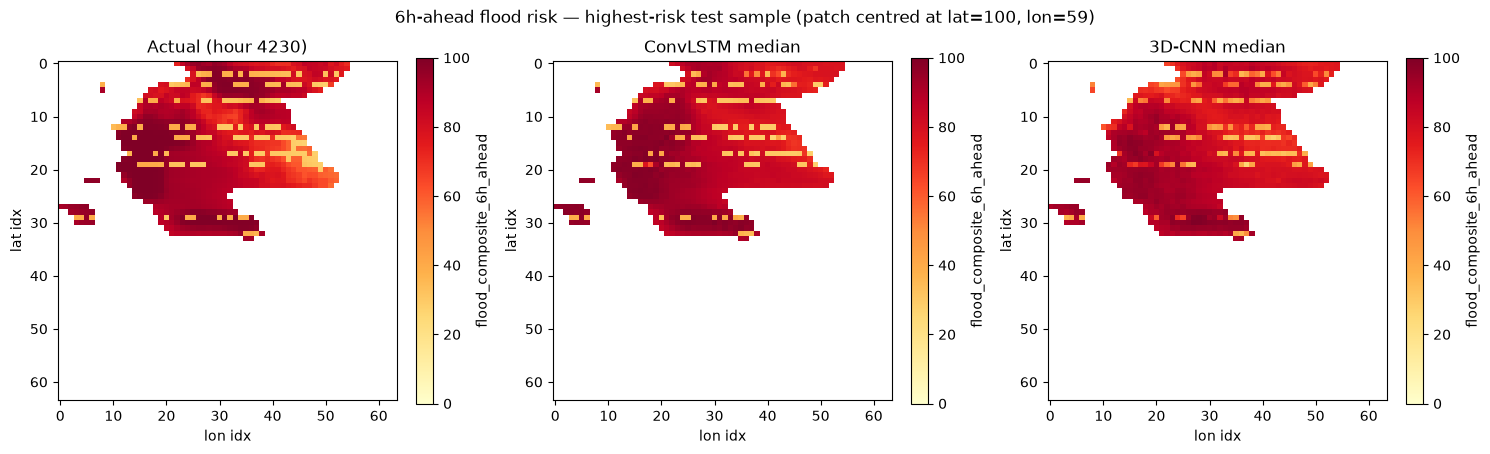

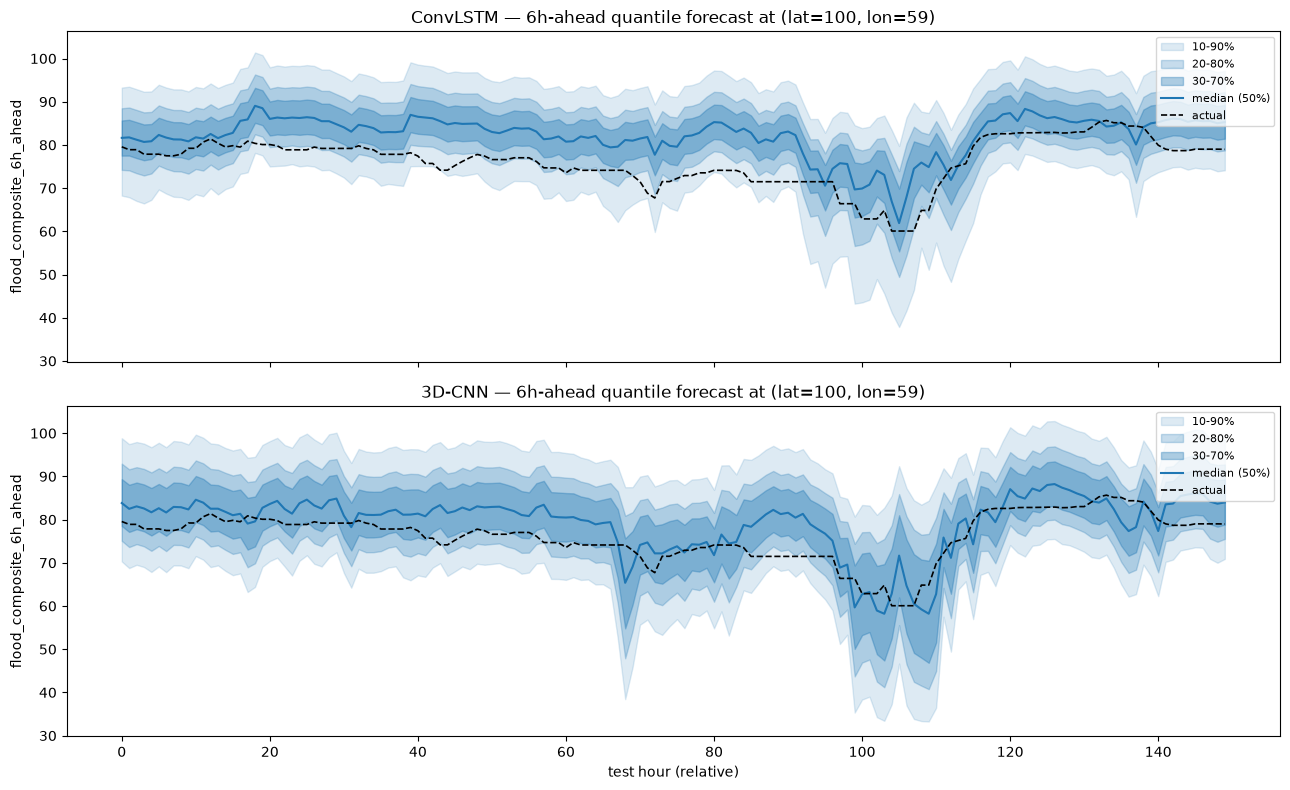

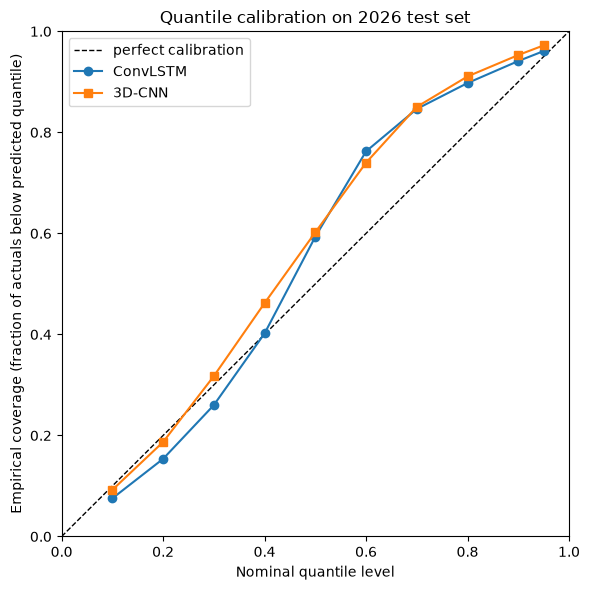

Saved: test_spatial_maps.png, test_quantile_fan.png, test_calibration.png
       -> W:\Dissertation\Volumes\Seagate_2TB\model_logs\


In [2]:
# VISUALISE TEST RESULTS — SPATIAL MAPS, QUANTILE FAN CHART, CALIBRATION
# ============================================================================
# Three views of the same 2026 test predictions:
#   1. Spatial maps  — actual vs ConvLSTM vs 3D-CNN median, for the
#      highest-risk sampled point (shows 6h-ahead spatial prediction).
#   2. Quantile fan chart — all 9 predicted quantiles over a run of
#      consecutive test hours at a fixed high-risk location, actual
#      overlaid (shows the probabilistic/quantile output over time).
#   3. Calibration plot — empirical coverage of each quantile vs its
#      nominal level, for both models (are the quantiles trustworthy?).
# ============================================================================
import numpy as np
import subprocess
import sys

# Install required packages if not present
packages = ["matplotlib", "seaborn", "scikit-learn"]
for package in packages:
    try:
        __import__(package)
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✓ {package} installed")

print("\n✓ All packages ready")
import torch

MED_IDX = QUANTILE_LEVELS.index(0.5)

# ── 1. Spatial maps: highest-risk sample among the 300 fixed test points ──
valid_target_max = np.nanmax(
    np.where(np.isnan(cl_targets), -np.inf, cl_targets).reshape(len(SAMPLES), -1),
    axis=1)
best_i = int(np.argmax(valid_target_max))
seq_end, (lat_c, lon_c) = SAMPLES[best_i]

actual   = np.ma.masked_invalid(cl_targets[best_i])
cl_med   = np.ma.masked_array(cl_preds[best_i, MED_IDX], mask=actual.mask)
c3_med   = np.ma.masked_array(c3_preds[best_i, MED_IDX], mask=actual.mask)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
vmax = max(np.nanmax(cl_targets[best_i]), 100)
for ax, data, title in zip(
        axes, [actual, cl_med, c3_med],
        [f"Actual (hour {seq_end})", "ConvLSTM median", "3D-CNN median"]):
    im = ax.imshow(data, cmap="YlOrRd", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("lon idx"); ax.set_ylabel("lat idx")
    plt.colorbar(im, ax=ax, fraction=0.046, label="flood_composite_6h_ahead")
fig.suptitle(f"6h-ahead flood risk — highest-risk test sample "
             f"(patch centred at lat={lat_c}, lon={lon_c})")
plt.tight_layout()
plt.savefig(r"W:\Dissertation\Volumes\Seagate_2TB\model_logs\test_spatial_maps.png",
            dpi=120, bbox_inches="tight")
plt.show()

# ── 2. Quantile fan chart at a fixed location over consecutive test hours ─
fan_lat, fan_lon = lat_c, lon_c
window = min(150, test_X.shape[0] - SEQ_LEN - 1)
fan_seq_ends = list(range(SEQ_LEN, SEQ_LEN + window))


def run_fan(model, mean, std):
    Xs = (test_X - mean) / std
    preds = []
    with torch.no_grad():
        for se in fan_seq_ends:
            x_seq = Xs[se-SEQ_LEN:se, :, fan_lat-HALF:fan_lat+HALF,
                       fan_lon-HALF:fan_lon+HALF]
            xb = torch.from_numpy(x_seq).float().unsqueeze(0).to(device)
            pred = model(xb, sort_quantiles=True)
            preds.append(pred[0, :, HALF, HALF].cpu().numpy())  # centre pixel
    return np.stack(preds)  # (window, 9)


cl_fan = run_fan(convlstm, cl_mean, cl_std)
c3_fan = run_fan(cnn3d, c3_mean, c3_std)
actual_fan = np.array([test_y[se, fan_lat, fan_lon] for se in fan_seq_ends])

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, sharey=True)
for ax, fan, title in zip(axes, [cl_fan, c3_fan], ["ConvLSTM", "3D-CNN"]):
    x = np.arange(window)
    ax.fill_between(x, fan[:, 0], fan[:, 8], alpha=0.15, color="tab:blue", label="10-90%")
    ax.fill_between(x, fan[:, 1], fan[:, 7], alpha=0.25, color="tab:blue", label="20-80%")
    ax.fill_between(x, fan[:, 2], fan[:, 6], alpha=0.35, color="tab:blue", label="30-70%")
    ax.plot(x, fan[:, MED_IDX], color="tab:blue", lw=1.5, label="median (50%)")
    ax.plot(x, actual_fan, color="black", lw=1.2, ls="--", label="actual")
    ax.set_title(f"{title} — 6h-ahead quantile forecast at "
                 f"(lat={fan_lat}, lon={fan_lon})")
    ax.set_ylabel("flood_composite_6h_ahead")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("test hour (relative)")
plt.tight_layout()
plt.savefig(r"W:\Dissertation\Volumes\Seagate_2TB\model_logs\test_quantile_fan.png",
            dpi=120, bbox_inches="tight")
plt.show()

# ── 3. Calibration: empirical coverage vs nominal quantile level ──────────
def coverage(preds, targets):
    mask = ~np.isnan(targets)
    cov = []
    for qi in range(len(QUANTILE_LEVELS)):
        below = (targets[mask] <= preds[:, qi][mask])
        cov.append(below.mean())
    return cov


cl_cov = coverage(cl_preds, cl_targets)
c3_cov = coverage(c3_preds, c3_targets)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
ax.plot(QUANTILE_LEVELS, cl_cov, "o-", label="ConvLSTM")
ax.plot(QUANTILE_LEVELS, c3_cov, "s-", label="3D-CNN")
ax.set_xlabel("Nominal quantile level")
ax.set_ylabel("Empirical coverage (fraction of actuals below predicted quantile)")
ax.set_title("Quantile calibration on 2026 test set")
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(r"W:\Dissertation\Volumes\Seagate_2TB\model_logs\test_calibration.png",
            dpi=120, bbox_inches="tight")
plt.show()

print("Saved: test_spatial_maps.png, test_quantile_fan.png, test_calibration.png")
print(f"       -> W:\\Dissertation\\Volumes\\Seagate_2TB\\model_logs\\")
